In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
import scipy.stats as stats
from scipy.stats import shapiro, levene
from statsmodels.stats.multicomp import MultiComparison
import pingouin as pg
from matplotlib.patches import Patch
import scikit_posthocs as sp
from scipy.stats import chi2_contingency, chisquare, fisher_exact
from scipy.stats import chi2
import platform
import warnings
import statsmodels.api as sm
import plotly.express as px
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import RobustScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import cliffs_delta
import re
from collections import defaultdict

warnings.filterwarnings('ignore')

# 운영체제별 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'

# 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

In [27]:
# cliffs_delta 출력
def get_sig_pairs_dunn(df, cluster_col, value_col, p_adjust="holm", alpha=0.05):
    """
    반환: [(i, j, pvalue), ...]  (i < j 형태로)
    """
    tmp = df[[cluster_col, value_col]].dropna()

    # Dunn test p-value matrix
    pmat = sp.posthoc_dunn(
        tmp,
        val_col=value_col,
        group_col=cluster_col,
        p_adjust=p_adjust
    )

    # 유의한 pair 뽑기
    clusters = sorted(pmat.index.tolist())
    sig_pairs = []
    for a_idx in range(len(clusters)):
        for b_idx in range(a_idx + 1, len(clusters)):
            i = clusters[a_idx]
            j = clusters[b_idx]
            p = float(pmat.loc[i, j])
            if p < alpha:
                sig_pairs.append((i, j, p))

    return sig_pairs


# =========================================================
# 1) cliffs_delta 계산 함수
# =========================================================
def compute_cliffs_by_variable(df, cluster_col, value_col, sig_pairs):
    """
    sig_pairs: [(i,j,p), ...]  또는 [(i,j), ...] 둘 다 허용
    반환: {(i,j): (delta, size), ...}
    """
    effect_sizes = {}

    for pair in sig_pairs:
        # (i, j, p) 형태든 (i, j) 형태든 처리
        if len(pair) == 3:
            i, j, _ = pair
        else:
            i, j = pair

        g1 = df[df[cluster_col] == i][value_col].dropna()
        g2 = df[df[cluster_col] == j][value_col].dropna()

        # 혹시 빈 그룹이면 스킵
        if len(g1) == 0 or len(g2) == 0:
            continue

        delta, size = cliffs_delta.cliffs_delta(g1, g2)
        effect_sizes[(i, j)] = (delta, size)

    return effect_sizes


# 결과 비교
# -----------------------------
# 0) 유틸: compute_cliffs_by_variable 결과에서 delta들만 뽑기
# -----------------------------
def _extract_deltas(effect_result):
    if effect_result is None:
        return np.array([])

    # DataFrame
    if isinstance(effect_result, pd.DataFrame):
        cols = [str(c) for c in effect_result.columns]
        delta_like = [c for c in cols if re.search(r"delta", c, re.IGNORECASE)]
        for c in delta_like:
            vals = pd.to_numeric(effect_result[c], errors="coerce").dropna().to_numpy()
            if len(vals):
                return vals.astype(float)
        num_cols = effect_result.select_dtypes(include=[np.number]).columns
        if len(num_cols) > 0:
            return effect_result[num_cols[0]].dropna().to_numpy(dtype=float)
        return np.array([])

    # dict
    if isinstance(effect_result, dict):
        deltas = []
        for v in effect_result.values():
            if v is None:
                continue

            # (1) 숫자면 그대로
            if isinstance(v, (int, float, np.number)):
                deltas.append(float(v))
                continue

            # (2) (delta, label) 튜플/리스트 형태 처리
            if isinstance(v, (tuple, list)) and len(v) >= 1:
                first = v[0]
                if isinstance(first, (int, float, np.number)):
                    deltas.append(float(first))
                    continue

            # (3) 내부 dict에 delta 키가 있는 경우
            if isinstance(v, dict):
                for kk, vv in v.items():
                    if vv is None:
                        continue
                    if re.search(r"delta", str(kk), re.IGNORECASE):
                        try:
                            deltas.append(float(vv))
                            break
                        except:
                            pass

        return np.array(deltas, dtype=float)

    # list/tuple (dict가 아닌 최상위 리스트 케이스)
    if isinstance(effect_result, (list, tuple)):
        deltas = []
        for v in effect_result:
            if v is None:
                continue
            if isinstance(v, (int, float, np.number)):
                deltas.append(float(v))
            elif isinstance(v, (tuple, list)) and len(v) >= 1 and isinstance(v[0], (int, float, np.number)):
                deltas.append(float(v[0]))
            elif isinstance(v, dict):
                for kk, vv in v.items():
                    if vv is None:
                        continue
                    if re.search(r"delta", str(kk), re.IGNORECASE):
                        try:
                            deltas.append(float(vv))
                            break
                        except:
                            pass
        return np.array(deltas, dtype=float)

    return np.array([])


# -----------------------------
# 1) 유틸: 가능한 모든 군집쌍 개수
# -----------------------------
def _n_all_pairs(df, cluster_col="Cluster"):
    k = df[cluster_col].nunique()
    return k * (k - 1) // 2


# -----------------------------
# 2) 데이터셋별 "군집 분리 점수" 계산
# -----------------------------
def score_cluster_separation(
    datasets,
    variables,
    cluster_col="군집",
    p_adjust="holm",
    alpha=0.05,
    strong_delta_thr=0.474,     # Cliff's delta 해석에서 'large' 기준으로 자주 쓰는 값
    weight_sig_ratio=1.0,
    weight_mean_delta=1.0,
    weight_strong_ratio=0.5,
    verbose=False
):
    """
    각 데이터셋에 대해:
      - 변수별 sig_pairs 생성 (Dunn)
      - 해당 sig_pairs에 대한 delta들 계산 (Cliff's)
      - 이를 요약해 데이터셋 점수화 + 랭킹

    반환:
      summary_df: 데이터셋별 요약 점수표
      detail: 데이터셋/변수별 상세(시그쌍 수, 평균 delta 등)
    """
    summary_rows = []
    detail = {}

    for data_name, df in datasets.items():
        detail[data_name] = {}

        total_all_pairs = _n_all_pairs(df, cluster_col)
        # 변수 여러 개니까 합산/평균을 낼 것
        total_sig_pairs = 0
        all_deltas = []

        for var_name, col_name in variables.items():
            # 1) 유의쌍
            sig_pairs = get_sig_pairs_dunn(
                df=df,
                cluster_col=cluster_col,
                value_col=col_name,
                p_adjust=p_adjust,
                alpha=alpha
            )
            n_sig = len(sig_pairs) if sig_pairs is not None else 0

            # 2) delta 계산 (유의쌍만)
            eff = compute_cliffs_by_variable(
                df=df,
                cluster_col=cluster_col,
                value_col=col_name,
                sig_pairs=sig_pairs
            )
            deltas = _extract_deltas(eff)

            total_sig_pairs += n_sig
            all_deltas.extend(list(deltas))

            # 변수별 detail 저장
            detail[data_name][var_name] = {
                "n_all_pairs": total_all_pairs,
                "n_sig_pairs": n_sig,
                "sig_ratio": (n_sig / total_all_pairs) if total_all_pairs > 0 else np.nan,
                "mean_abs_delta": float(np.mean(np.abs(deltas))) if len(deltas) else np.nan,
                "strong_ratio": float(np.mean(np.abs(deltas) >= strong_delta_thr)) if len(deltas) else np.nan,
            }

        all_deltas = np.array(all_deltas, dtype=float)
        sig_ratio_overall = (total_sig_pairs / (total_all_pairs * len(variables))) if total_all_pairs > 0 else np.nan

        mean_abs_delta_overall = float(np.mean(np.abs(all_deltas))) if len(all_deltas) else np.nan
        strong_ratio_overall = float(np.mean(np.abs(all_deltas) >= strong_delta_thr)) if len(all_deltas) else np.nan

        # 최종 점수
        # - 유의쌍 비율이 높고
        # - delta가 크고
        # - strong 비율이 높을수록 점수↑
        score = (
            (sig_ratio_overall ** weight_sig_ratio)
            * ((mean_abs_delta_overall if not np.isnan(mean_abs_delta_overall) else 0.0) ** weight_mean_delta)
            * (1.0 + weight_strong_ratio * (strong_ratio_overall if not np.isnan(strong_ratio_overall) else 0.0))
        )

        summary_rows.append({
            "데이터셋": data_name,
            "군집수": df[cluster_col].nunique(),
            "sig": round(sig_ratio_overall, 3),           # (변수별 sig_ratio 평균)
            "M.A.D": round(mean_abs_delta_overall, 3), # (유의쌍 delta들 전체 평균)
            "strong": round(strong_ratio_overall, 3),     # (|delta|>=thr 비율)
            "score": round(score, 3)
        })

        if verbose:
            print(f"[{data_name}] score={score:.4f}, sig_ratio={sig_ratio_overall:.3f}, mean|d|={mean_abs_delta_overall:.3f}")

    summary_df = pd.DataFrame(summary_rows).sort_values("score", ascending=False).reset_index(drop=True)
    return summary_df, detail

def rank_clusters_from_cliffs(cliffs_dict):
    """
    cliffs_dict: {(i, j): (delta, size)}
    return: DataFrame with score, wins, losses, rank
    """

    scores = defaultdict(float)
    wins = defaultdict(int)
    losses = defaultdict(int)

    for (i, j), (delta, size) in cliffs_dict.items():
        weight = abs(delta)

        if delta > 0:
            # i > j
            scores[i] += weight
            scores[j] -= weight
            wins[i] += 1
            losses[j] += 1
        elif delta < 0:
            # j > i
            scores[j] += weight
            scores[i] -= weight
            wins[j] += 1
            losses[i] += 1

    clusters = sorted(set([c for pair in cliffs_dict for c in pair]))

    df_rank = pd.DataFrame({
        "군집": clusters,
        "Score": [scores[c] for c in clusters],
        "Wins": [wins[c] for c in clusters],
        "Losses": [losses[c] for c in clusters],
    })

    df_rank = df_rank.sort_values("Score", ascending=False).reset_index(drop=True)
    df_rank["Rank"] = df_rank.index + 1

    return df_rank

def compute_cliffs_from_pairs(df, value_col, cluster_col, sig_pairs):
    """
    df          : DataFrame
    value_col   : 비교할 수치형 변수 (예: '관광인프라')
    cluster_col : 군집 컬럼명 (예: 'Cluster')
    sig_pairs   : [(i, j, p_value), ...]
    
    return:
        {(i, j): (delta, size)}
    """
    effect_sizes = {}

    for i, j, _ in sig_pairs:
        g1 = df[df[cluster_col] == i][value_col]
        g2 = df[df[cluster_col] == j][value_col]

        delta, size = cliffs_delta.cliffs_delta(g1, g2)
        effect_sizes[(i, j)] = (delta, size)

    return effect_sizes

# 데이터별로 {데이터명}_순위 변수 생성

def build_one_dataset_rank_table(effect_sizes_by_var, prefix="등"):
    """
    effect_sizes_by_var: {var_name: effect_sizes_dict}
    반환: index=피처, columns=1등..K등, values=cluster id
    """
    rows = {}
    max_rank = 0

    for var_name, effect_sizes in effect_sizes_by_var.items():
        if not effect_sizes or (isinstance(effect_sizes, dict) and len(effect_sizes) == 0):
            rows[var_name] = []
            continue

        rank_df = rank_clusters_from_cliffs(effect_sizes)
        order = rank_df.sort_values("Rank")["군집"].astype(int).tolist()

        rows[var_name] = order
        max_rank = max(max_rank, len(order))

    cols = [f"{i}{prefix}" for i in range(1, max_rank + 1)]
    out = pd.DataFrame(index=list(rows.keys()), columns=cols)

    for var_name, order in rows.items():
        padded = order + [np.nan] * (max_rank - len(order))
        out.loc[var_name, :] = padded

    return out

In [28]:
df_기본 = pd.read_csv('df_기본.csv')
df_관광접근성_유클리드_4 = pd.read_csv('df_관광접근성_유클리드_4.csv')
df_관광접근성_유클리드_5 = pd.read_csv('df_관광접근성_유클리드_5.csv')
df_관광접근성_코사인_4 = pd.read_csv('df_관광접근성_코사인_4.csv')
df_관광접근성_코사인_5 = pd.read_csv('df_관광접근성_코사인_5.csv')
df_마인드_유클리드_4 = pd.read_csv('df_마인드_유클리드_4.csv')
df_마인드_유클리드_5 = pd.read_csv('df_마인드_유클리드_5.csv')
df_마인드_코사인_4 = pd.read_csv('df_마인드_코사인_4.csv')
df_마인드_코사인_5 = pd.read_csv('df_마인드_코사인_5.csv')
df_접근성따로마인드_유클리드_4 = pd.read_csv('df_접근성따로마인드_유클리드_4.csv')
df_접근성따로마인드_유클리드_5 = pd.read_csv('df_접근성따로마인드_유클리드_5.csv')
df_접근성따로마인드_코사인_4 = pd.read_csv('df_접근성따로마인드_코사인_4.csv')
df_접근성따로마인드_코사인_5 = pd.read_csv('df_접근성따로마인드_코사인_5.csv')
df_하이킹_유클리드_5 = pd.read_csv('df_하이킹_유클리드_5.csv')
df_하이킹_유클리드_6 = pd.read_csv('df_하이킹_유클리드_6.csv')
df_하이킹_코사인_4 = pd.read_csv('df_하이킹_코사인_4.csv')
df_하이킹_코사인_5 = pd.read_csv('df_하이킹_코사인_5.csv')
df_접근성따로하이킹_유클리드_4 = pd.read_csv('df_접근성따로하이킹_유클리드_4.csv')
df_접근성따로하이킹_유클리드_5 = pd.read_csv('df_접근성따로하이킹_유클리드_5.csv')
df_접근성따로하이킹_코사인_4 = pd.read_csv('df_접근성따로하이킹_코사인_4.csv')
df_접근성따로하이킹_코사인_5 = pd.read_csv('df_접근성따로하이킹_코사인_5.csv')
df_힐링_유클리드_4 = pd.read_csv('df_힐링_유클리드_4.csv')
df_힐링_유클리드_5 = pd.read_csv('df_힐링_유클리드_5.csv')
df_힐링_코사인_4 = pd.read_csv('df_힐링_코사인_4.csv')
df_힐링_코사인_5 = pd.read_csv('df_힐링_코사인_5.csv')
df_접근성따로힐링_유클리드_4 = pd.read_csv('df_접근성따로힐링_유클리드_4.csv')
df_접근성따로힐링_유클리드_5 = pd.read_csv('df_접근성따로힐링_유클리드_5.csv')
df_접근성따로힐링_코사인_4 = pd.read_csv('df_접근성따로힐링_코사인_4.csv')
df_접근성따로힐링_코사인_5 = pd.read_csv('df_접근성따로힐링_코사인_5.csv')

In [29]:
all_effect_sizes = {}

datasets = {
    'A데이터': df_기본,
    'B_1데이터': df_관광접근성_유클리드_4,
    'B_2데이터': df_관광접근성_유클리드_5,
    'C_1데이터': df_관광접근성_코사인_4,
    'C_2데이터': df_관광접근성_코사인_5,
    'D_1데이터': df_마인드_유클리드_4,
    'D_2데이터': df_마인드_유클리드_5,
    'E_1데이터': df_마인드_코사인_4,
    'E_2데이터': df_마인드_코사인_5,
    'F_1데이터': df_접근성따로마인드_유클리드_4,
    'F_2데이터': df_접근성따로마인드_유클리드_5,
    'G_1데이터': df_접근성따로마인드_코사인_4,
    'G_2데이터': df_접근성따로마인드_코사인_5,
    'H_1데이터': df_하이킹_유클리드_5,
    'H_2데이터': df_하이킹_유클리드_6,
    'I_1데이터': df_하이킹_코사인_4,
    'I_2데이터': df_하이킹_코사인_5,
    'J_1데이터': df_접근성따로하이킹_유클리드_4,
    'J_2데이터': df_접근성따로하이킹_유클리드_5,
    'K_1데이터': df_접근성따로하이킹_코사인_4,
    'K_2데이터': df_접근성따로하이킹_코사인_5,
    'L_1데이터': df_힐링_유클리드_4,
    'L_2데이터': df_힐링_유클리드_5,
    'M_1데이터': df_힐링_코사인_4,
    'M_2데이터': df_힐링_코사인_5,
    'O_1데이터': df_접근성따로힐링_유클리드_4,
    'O_2데이터': df_접근성따로힐링_유클리드_5,
    'P_1데이터': df_접근성따로힐링_코사인_4,
    'P_2데이터': df_접근성따로힐링_코사인_5,
    # 필요하면 계속 추가
}

variables = {
    "관광인프라": "관광인프라",
    "접근성": "주차장_접근성",
    "매력종합": "매력종합점수",
    "전망": "전망",
    "힐링": "힐링",
    "사진": "사진",
    "등산로": "등산로",
    "성취감": "성취감",
    "계절매력": "계절매력"
}

cluster_col = "군집"

all_effect_sizes = {}

for data_name, df in datasets.items():
    all_effect_sizes[data_name] = {}

    for var_name, col_name in variables.items():
        # 3-1) 이 "/변수" 조합에 대한 sig_pairs 생성
        sig_pairs = get_sig_pairs_dunn(
            df=df,
            cluster_col=cluster_col,
            value_col=col_name,
            p_adjust="holm",
            alpha=0.05
        )

        # 3-2) sig_pairs에 대해서만 cliffs_delta 계산
        all_effect_sizes[data_name][var_name] = compute_cliffs_by_variable(
            df=df,
            cluster_col=cluster_col,
            value_col=col_name,
            sig_pairs=sig_pairs
        )


# =========================================================
# 4) 출력 (네가 원한 포맷)
# =========================================================
for data_name, vars_dict in all_effect_sizes.items():
    print(f"\n📌 {data_name}")
    for var_name, results in vars_dict.items():
        print(var_name)
        print(results)


📌 A데이터
관광인프라
{(0, 1): (-0.5346024191949237, 'large'), (0, 4): (-0.6633920505871725, 'large'), (1, 2): (0.3615576496674058, 'medium'), (1, 3): (0.4951314048024201, 'large'), (1, 4): (-0.20617378048780488, 'small'), (2, 4): (-0.5369318181818182, 'large'), (3, 4): (-0.6321597760551249, 'large')}
접근성
{(0, 1): (-0.991076740035693, 'large'), (0, 2): (-0.28917220990391723, 'small'), (0, 3): (-0.8937417281149556, 'large'), (0, 4): (-0.9877484191508582, 'large'), (1, 2): (0.6556263858093127, 'large'), (2, 3): (-0.5822762508809021, 'large'), (2, 4): (-0.6594065656565656, 'large')}
매력종합
{(0, 1): (0.3934661907594686, 'medium'), (0, 2): (0.9987065779748706, 'large'), (0, 3): (-0.5310392638810109, 'large'), (0, 4): (-0.7406278229448962, 'large'), (1, 2): (0.9605044345898004, 'large'), (1, 3): (-0.859708829646436, 'large'), (1, 4): (-0.9713753387533876, 'large'), (2, 3): (-1.0, 'large'), (2, 4): (-1.0, 'large'), (3, 4): (-0.4041236003445306, 'medium')}
전망
{(0, 1): (0.3720999405116002, 'medium'), (0,

In [30]:
summary_df, detail = score_cluster_separation(
    datasets=datasets,
    variables=variables,
    cluster_col="군집",
    p_adjust="holm",
    alpha=0.05,
    strong_delta_thr=0.474,   
    verbose=True
)


[A데이터] score=0.7078, sig_ratio=0.800, mean|d|=0.653
[B_1데이터] score=0.6757, sig_ratio=0.741, mean|d|=0.657
[B_2데이터] score=0.6797, sig_ratio=0.822, mean|d|=0.624
[C_1데이터] score=0.6448, sig_ratio=0.852, mean|d|=0.580
[C_2데이터] score=0.6865, sig_ratio=0.867, mean|d|=0.600
[D_1데이터] score=0.6231, sig_ratio=0.778, mean|d|=0.612
[D_2데이터] score=0.6190, sig_ratio=0.767, mean|d|=0.622
[E_1데이터] score=0.5998, sig_ratio=0.815, mean|d|=0.578
[E_2데이터] score=0.6068, sig_ratio=0.778, mean|d|=0.603
[F_1데이터] score=0.5927, sig_ratio=0.815, mean|d|=0.572
[F_2데이터] score=0.6635, sig_ratio=0.767, mean|d|=0.653
[G_1데이터] score=0.6281, sig_ratio=0.852, mean|d|=0.570
[G_2데이터] score=0.6439, sig_ratio=0.756, mean|d|=0.637
[H_1데이터] score=0.6468, sig_ratio=0.778, mean|d|=0.623
[H_2데이터] score=0.7156, sig_ratio=0.793, mean|d|=0.666
[I_1데이터] score=0.6161, sig_ratio=0.907, mean|d|=0.537
[I_2데이터] score=0.6376, sig_ratio=0.811, mean|d|=0.595
[J_1데이터] score=0.5810, sig_ratio=0.741, mean|d|=0.603
[J_2데이터] score=0.6275, sig_rat

In [31]:
summary_df.sort_values('score', ascending = False).head(5)

,데이터셋,군집수,sig,M.A.D,strong,score
0,H_2데이터,6,0.793,0.666,0.710,0.716
1,O_2데이터,5,0.811,0.646,0.712,0.710
2,A데이터,5,0.800,0.653,0.708,0.708
3,P_2데이터,5,0.778,0.658,0.743,0.702
4,C_2데이터,5,0.867,0.600,0.641,0.687


In [32]:
# 군집 간 비교 중에서, 통계적으로 유의한 차이를 보인 비율

summary_df.sort_values('strong', ascending = False).head(5)

,데이터셋,군집수,sig,M.A.D,strong,score
6,B_1데이터,4,0.741,0.657,0.775,0.676
3,P_2데이터,5,0.778,0.658,0.743,0.702
1,O_2데이터,5,0.811,0.646,0.712,0.710
0,H_2데이터,6,0.793,0.666,0.710,0.716
2,A데이터,5,0.800,0.653,0.708,0.708


In [33]:
# 효과크기 기반 분리 강도

summary_df.sort_values('M.A.D', ascending = False).head(5)

,데이터셋,군집수,sig,M.A.D,strong,score
0,H_2데이터,6,0.793,0.666,0.710,0.716
3,P_2데이터,5,0.778,0.658,0.743,0.702
6,B_1데이터,4,0.741,0.657,0.775,0.676
19,J_2데이터,5,0.711,0.657,0.688,0.628
11,F_2데이터,5,0.767,0.653,0.652,0.663


In [34]:
# 강한 분리의 비율

summary_df.sort_values('sig', ascending = False).head(5)

,데이터셋,군집수,sig,M.A.D,strong,score
22,I_1데이터,4,0.907,0.537,0.531,0.616
13,P_1데이터,4,0.889,0.564,0.583,0.647
8,O_1데이터,4,0.870,0.586,0.638,0.672
4,C_2데이터,5,0.867,0.600,0.641,0.687
7,L_1데이터,4,0.852,0.603,0.630,0.675


In [35]:
rank_tables = {}

for data_name, vars_dict in all_effect_sizes.items():
    df_rank = build_one_dataset_rank_table(vars_dict, prefix="등")
 
    rank_tables[data_name] = df_rank  

print("✅ 생성 완료:")


✅ 생성 완료:


In [36]:
rank_tables['H_2데이터']

,1등,2등,3등,4등,5등,6등
관광인프라,3,2,1,0,4,5
접근성,3,2,0,4,1,5
매력종합,2,0,4,5,3,1
전망,2,0,5,3,4,1
힐링,4,0,5,3,1,2
사진,2,0,5,3,4,1
등산로,2,4,3,0,5,1
성취감,2,5,0,3,4,1
계절매력,0,4,2,5,1,3


In [37]:
rank_tables['A데이터']

,1등,2등,3등,4등,5등
관광인프라,4,1,2,3,0
접근성,4,1,3,2,0
매력종합,4,3,0,1,2
전망,4,3,0,1,2
힐링,3,0,1,4,2
사진,4,3,0,1,2
등산로,4,3,0,1,2
성취감,4,0,3,1,2
계절매력,3,0,4,2,1


In [38]:
rank_tables['B_1데이터']


,1등,2등,3등,4등
관광인프라,1,0,2,3
접근성,0,1,2,3
매력종합,0,2,1,3
전망,0,1,2,3
힐링,2,1,3,0
사진,0,2,1,3
등산로,0,1,2,3
성취감,0,3,1,2
계절매력,2,0,3,1


In [39]:
rank_tables['C_1데이터']

,1등,2등,3등,4등
관광인프라,0,3,1,2
접근성,0,2,3,1
매력종합,3,2,0,1
전망,3,2,0,1
힐링,2,0,1,3
사진,3,2,0,1
등산로,0,3,2,1
성취감,3,2,1,0
계절매력,2,3,1,0


In [40]:
rank_tables['C_2데이터']

,1등,2등,3등,4등,5등
관광인프라,2,0,3,1,4
접근성,2,1,0,3,4
매력종합,0,1,2,4,3
전망,0,1,2,4,3
힐링,1,2,4,0,3
사진,0,1,2,4,3
등산로,2,0,1,4,3
성취감,0,4,3,1,2
계절매력,1,0,4,3,2


In [41]:
rank_tables['E_1데이터']

,1등,2등,3등,4등
관광인프라,0,2,1,3
접근성,0,2,3,1
매력종합,2,3,0,1
전망,2,3,0,1
힐링,3,2,0,1
사진,2,3,0,1
등산로,0,2,3,1
성취감,2,3,1,0
계절매력,3,2,1,0


In [42]:
rank_tables['F_2데이터']

,1등,2등,3등,4등,5등
관광인프라,2,4,3,1,0
접근성,1,4,2,3,0
매력종합,4,1,0,2,3
전망,4,1,0,2,3
힐링,1,0,2,4,3
사진,4,1,0,2,3
등산로,4,2,0,1,3
성취감,4,0,1,3,2
계절매력,1,0,4,3,2


In [43]:
rank_tables['G_1데이터']

,1등,2등,3등,4등
관광인프라,0,2,3,1
접근성,1,0,2,3
매력종합,1,0,3,2
전망,0,1,3,2
힐링,1,3,2,0
사진,0,1,3,2
등산로,0,1,3,2
성취감,1,0,3,2
계절매력,1,3,0,2


In [44]:
rank_tables['I_1데이터']

,1등,2등,3등,4등
관광인프라,3,1,0,2
접근성,3,0,1,2
매력종합,3,0,2,1
전망,3,0,2,1
힐링,0,2,1,3
사진,3,0,2,1
등산로,3,0,2,1
성취감,3,2,0,1
계절매력,0,2,3,1


In [45]:
rank_tables['J_2데이터']

,1등,2등,3등,4등,5등
관광인프라,1,0,3,2,4
접근성,4,1,2,0,3
매력종합,4,1,3,2,0
전망,4,1,3,2,0
힐링,2,4,3,0,1
사진,4,1,3,2,0
등산로,1,2,4,3,0
성취감,4,3,1,2,0
계절매력,4,2,3,0,1


In [46]:
rank_tables['L_1데이터']

,1등,2등,3등,4등
관광인프라,1,0,2,3
접근성,0,1,2,3
매력종합,1,0,3,2
전망,1,0,3,2
힐링,0,3,1,2
사진,1,0,3,2
등산로,0,1,3,2
성취감,1,3,2,0
계절매력,1,3,0,2


In [47]:
rank_tables['O_1데이터']

,1등,2등,3등,4등
관광인프라,2,0,1,3
접근성,2,3,0,1
매력종합,0,3,2,1
전망,0,3,2,1
힐링,3,2,1,0
사진,0,3,2,1
등산로,0,2,3,1
성취감,0,3,1,2
계절매력,3,0,1,2


In [48]:
rank_tables['O_2데이터']

,1등,2등,3등,4등,5등
관광인프라,0,3,4,1,2
접근성,1,0,3,4,2
매력종합,3,1,2,0,4
전망,3,1,2,0,4
힐링,1,0,2,3,4
사진,3,1,2,0,4
등산로,0,3,1,2,4
성취감,3,2,1,4,0
계절매력,1,3,2,0,4


In [49]:
rank_tables['P_1데이터']

,1등,2등,3등,4등
관광인프라,0,2,1,3
접근성,0,3,2,1
매력종합,2,3,0,1
전망,2,3,0,1
힐링,3,0,1,2
사진,2,3,0,1
등산로,2,0,3,1
성취감,2,3,1,0
계절매력,3,2,1,0


In [50]:
rank_tables['P_2데이터']

,1등,2등,3등,4등,5등
관광인프라,0,4,3,1,2
접근성,1,0,4,3,2
매력종합,4,1,2,0,3
전망,4,1,0,2,3
힐링,1,0,2,4,3
사진,4,1,0,2,3
등산로,0,4,1,2,3
성취감,4,1,2,3,0
계절매력,1,4,2,0,3


In [51]:
df = df_하이킹_유클리드_6.copy()

In [54]:
df.groupby('군집')[['관광편의성', '경관감성', '산행경험', '힐링', '계절매력']].mean().round(1)

,관광편의성,경관감성,산행경험,힐링,계절매력
군집,,,,,
0,6.8,7.8,6.8,7.1,8.3
1,5.0,6.7,6.2,7.0,7.3
2,7.8,8.0,7.2,7.0,7.6
3,7.7,7.5,6.8,7.0,7.3
4,6.6,7.4,6.8,7.5,7.8
5,3.1,7.6,6.8,7.0,7.6


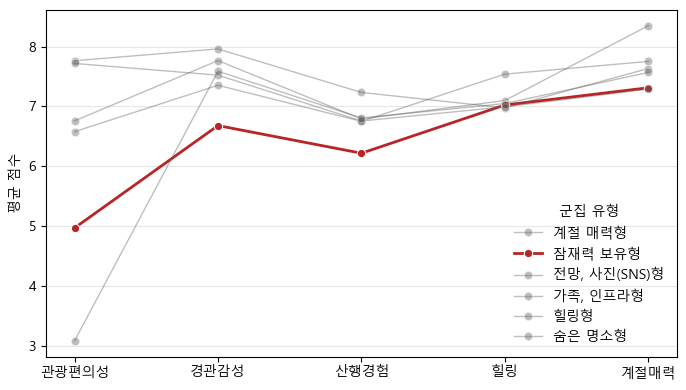

In [ ]:
# =========================
# 설정
# =========================
cols = ['관광편의성', '경관감성', '산행경험', '힐링', '계절매력']
cluster_col = '군집'

highlight_cluster = 1
highlight_color = "#b92525"
background_color = "#5e5e5e"

order = cols

# 🔹 군집 이름 매핑
cluster_name_map = {
    0: '계절 매력형',
    1: '잠재력 보유형',
    2: '전망, 사진(SNS)형',
    3: '가족, 인프라형',
    4: '힐링형',
    5: '숨은 명소형'
}

# =========================
# 1) 군집 × 피처 평균
# =========================
df_mean = (
    df
    .groupby(cluster_col)[cols]
    .mean()
    .reset_index()
)

# =========================
# 2) long-format
# =========================
df_long = df_mean.melt(
    id_vars=cluster_col,
    var_name='지표',
    value_name='평균값'
)

# =========================
# 3) 색상 팔레트
# =========================
clusters = df_long[cluster_col].unique()

palette = {
    c: (highlight_color if c == highlight_cluster else background_color)
    for c in clusters
}

# =========================
# 4) 꺾은선 그래프
# =========================
plt.figure(figsize=(7, 4))

ax = sns.lineplot(
    data=df_long,
    x='지표',
    y='평균값',
    hue=cluster_col,
    palette=palette,
    marker='o',
    linewidth=2,
    legend=True
)

# =========================
# 5) 배경 군집 약화
# =========================
for line in ax.lines:
    if line.get_color() == background_color:
        line.set_alpha(0.4)
        line.set_linewidth(1)

# =========================
# 6) 범례 이름 교체
# =========================
handles, labels = ax.get_legend_handles_labels()

new_labels = [
    cluster_name_map[int(l)] if l.isdigit() else l
    for l in labels
]

ax.legend(
    handles,
    new_labels,
    title='군집 유형',
    frameon=False
)

# =========================
# 7) 마무리
# =========================
plt.ylabel('평균 점수')
plt.xlabel('')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()
